# Computer Exercise 14.3 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 응용 사례연구 III (§14.3)
> **단원**: §14.3 End-to-End Case Study — **1단계: 모델 선택 (Model Selection)**
> **풀이 일자**: 2026-07-03 · **언어**: 한국어 본문 / 영문 그래프 라벨

이번 §14.3은 §14.2에서 따로 놀던 세 도구(예측구간 · 평활 선택 · 하이퍼파라미터 탐색)를 **하나의 파이프라인**으로 엮는다:
$$\text{원자료}\;\to\;\boxed{\textbf{모델 선택}}\;\to\;\text{예측 + 불확실성}\;\to\;\text{하이퍼파라미터 조정}.$$
Problem 1은 그 **첫 관문** — *잡음만 보이는 데이터에서 "얼마나 복잡한 모델을 쓸 것인가"* 를 데이터가 스스로 고르게 한다.

## 1. 문제 (원문)

> **1.** You are given noisy observations $\{(x_i,y_i)\}_{i=1}^{n}$ of an unknown smooth function on $[0,1]$.
> Fit polynomial models of degree $d = 0,1,\dots,12$ by least squares. For each degree compute the
> **training RMSE**, a **$K$-fold cross-validated RMSE**, and the information criteria **AIC** and **BIC**.
> Plot training error and CV error against degree, and identify the degree selected by (a) minimum CV error
> and (b) minimum BIC. Discuss why the training error alone is a misleading guide, and relate the CV curve
> to the **bias-variance trade-off**.

### 한국어 풀이용 정리
- 미지의 매끄러운 함수 + 정규잡음으로 합성 데이터를 만든다(참함수는 적합에 쓰지 않는다).
- 차수 $d=0..12$ 다항식을 최소제곱 적합하고 **훈련 RMSE**, **$K$-겹 CV RMSE**, **AIC/BIC** 를 계산.
- CV 최소 차수와 BIC 최소 차수를 찾아 "훈련오차만 보면 왜 속는가"를 편향-분산으로 설명한다.
- 이 선택된 복잡도가 다음 단계(Problem 2의 예측+불확실성)의 입력이 된다.

## 2. 수학적 배경

### 2.1 다항 최소제곱과 자유도
차수 $d$ 다항식 $p_d(x)=\sum_{j=0}^{d}\beta_j x^{j}$ 를 설계행렬 $X\in\mathbb{R}^{n\times(d+1)}$ 로 적합하면
$$\hat{\boldsymbol\beta}=(X^\top X)^{-1}X^\top \mathbf y,\qquad \text{모수 개수 } p=d+1.$$

### 2.2 훈련오차 vs 일반화오차
훈련 RMSE $=\sqrt{\tfrac1n\sum_i (y_i-\hat y_i)^2}$ 는 $d$ 가 커질수록 **단조 감소**한다(자유도가 늘며 잡음까지 적합). 이는 일반화 성능의 지표가 **아니다**. 새 데이터에 대한 기대오차는
$$\mathbb E[(y-\hat p(x))^2]=\underbrace{\sigma^2}_{\text{irreducible}}+\underbrace{\text{Bias}^2}_{\downarrow\, d}+\underbrace{\text{Var}}_{\uparrow\, d},$$
즉 $d$ 에 대해 **U자형**을 그린다(편향-분산 트레이드오프).

### 2.3 교차검증(CV)과 정보기준
$K$-겹 CV는 데이터를 $K$ 조각으로 나눠 각 조각을 한 번씩 검증에 쓴다:
$$\mathrm{CV}_K=\sqrt{\tfrac1n\sum_{k=1}^{K}\sum_{i\in \text{fold }k}\big(y_i-\hat p^{(-k)}(x_i)\big)^2}.$$
정보기준은 적합도(우도)에 복잡도 벌점을 더한다. 가우스 잡음 가정에서
$$\mathrm{AIC}=n\ln\!\big(\mathrm{RSS}/n\big)+2p,\qquad
\boxed{\;\mathrm{BIC}=n\ln\!\big(\mathrm{RSS}/n\big)+p\ln n\;}$$
BIC의 벌점 $p\ln n$ 이 더 강해 **더 단순한 모델**을 선호한다.

## 3. 풀이 흐름
1. **참함수** $g(x)=\sin(2\pi x)+0.5\,x$ (적합엔 비공개) 와 관측잡음 $\sigma$ 로 $n=40$ 표본 생성.
2. 차수 $d=0..12$ 각각에 대해 다항 최소제곱 적합 → **훈련 RMSE** 계산.
3. **$K=5$-겹 CV** 로 검증 RMSE 계산(폴드 셔플 고정 시드).
4. 각 차수의 **RSS** 로 **AIC·BIC** 계산.
5. **표**로 degree별 train/CV/AIC/BIC 정리, 각 기준의 최소 지점 표시.
6. **그림 1**: train vs CV RMSE(로그축) — 훈련은 단조감소, CV는 U자형.
7. **그림 2**: underfit·best·overfit 세 차수의 적합곡선 비교.
8. 결과 해석 — 선택 복잡도를 다음 단계로 전달.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(14303)

# --- 1) 합성 데이터 (참함수는 이후 적합에 사용하지 않음) ---
def g_true(x):
    return np.sin(2*np.pi*x) + 0.5*x

n = 40
sigma = 0.25
x = np.sort(rng.uniform(0, 1, n))
y = g_true(x) + rng.normal(0, sigma, n)

degrees = np.arange(0, 13)

def poly_fit_predict(xtr, ytr, xte, d):
    coef = np.polyfit(xtr, ytr, d)      # 내부 QR: 수치적으로 안정
    return np.polyval(coef, xte)

# --- 2) 훈련 RMSE / RSS ---
train_rmse, rss_full = [], []
for d in degrees:
    yhat = poly_fit_predict(x, y, x, d)
    r = y - yhat
    train_rmse.append(np.sqrt(np.mean(r**2)))
    rss_full.append(np.sum(r**2))
train_rmse = np.array(train_rmse); rss_full = np.array(rss_full)

# --- 3) K=5 겹 CV RMSE ---
K = 5
folds = np.array_split(rng.permutation(n), K)
cv_rmse = []
for d in degrees:
    sq = []
    for k in range(K):
        te = folds[k]
        tr = np.concatenate([folds[j] for j in range(K) if j != k])
        yhat = poly_fit_predict(x[tr], y[tr], x[te], d)
        sq.extend((y[te] - yhat)**2)
    cv_rmse.append(np.sqrt(np.mean(sq)))
cv_rmse = np.array(cv_rmse)

# --- 4) AIC / BIC ---
p = degrees + 1
aic = n*np.log(rss_full/n) + 2*p
bic = n*np.log(rss_full/n) + p*np.log(n)

d_cv, d_aic, d_bic = degrees[np.argmin(cv_rmse)], degrees[np.argmin(aic)], degrees[np.argmin(bic)]
print(f"CV-min degree  = {d_cv}")
print(f"AIC-min degree = {d_aic}")
print(f"BIC-min degree = {d_bic}")

/tmp/mpl is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-2o4883ul because there was an issue with the default path (/tmp/mpl); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


CV-min degree  = 5
AIC-min degree = 5
BIC-min degree = 5


In [2]:
# --- 5) 표 ---
df = pd.DataFrame({
    "degree": degrees, "params": p,
    "train_RMSE": train_rmse, "CV_RMSE": cv_rmse,
    "AIC": aic, "BIC": bic,
})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("degree별 적합 진단 (각 열 최소값 = 그 기준이 고른 복잡도)")
print(df.to_string(index=False))

degree별 적합 진단 (각 열 최소값 = 그 기준이 고른 복잡도)
 degree  params  train_RMSE  CV_RMSE       AIC      BIC
      0       1      0.6521   0.6584  -32.2002 -30.5113
      1       2      0.5115   0.5233  -49.6375 -46.2598
      2       3      0.5110   0.5573  -47.7054 -42.6387
      3       4      0.2588   0.2920 -100.1456 -93.3901
      4       5      0.2568   0.2923  -98.7638 -90.3194
      5       6      0.2331   0.2770 -104.4957 -94.3624
      6       7      0.2331   0.2797 -102.4978 -90.6756
      7       8      0.2330   0.2925 -100.5216 -87.0106
      8       9      0.2271   0.2941 -100.6010 -85.4010
      9      10      0.2269   0.3168  -98.6758 -81.7871
     10      11      0.2266   0.3110  -96.7598 -78.1821
     11      12      0.2266   0.3156  -94.7598 -74.4933
     12      13      0.2266   0.5069  -92.7603 -70.8049


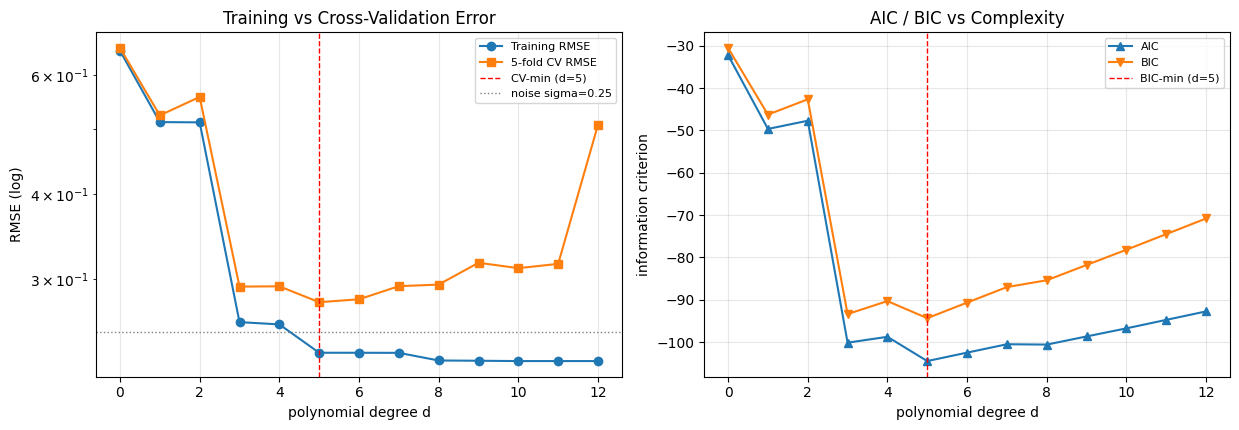

In [3]:
# --- 6) 그림 1: train vs CV / AIC·BIC ---
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax[0].plot(degrees, train_rmse, "o-", label="Training RMSE")
ax[0].plot(degrees, cv_rmse, "s-", label="5-fold CV RMSE")
ax[0].axvline(d_cv, color="red", ls="--", lw=1, label=f"CV-min (d={d_cv})")
ax[0].axhline(sigma, color="gray", ls=":", lw=1, label=f"noise sigma={sigma}")
ax[0].set_yscale("log")
ax[0].set_xlabel("polynomial degree d"); ax[0].set_ylabel("RMSE (log)")
ax[0].set_title("Training vs Cross-Validation Error")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(degrees, aic, "^-", label="AIC")
ax[1].plot(degrees, bic, "v-", label="BIC")
ax[1].axvline(d_bic, color="red", ls="--", lw=1, label=f"BIC-min (d={d_bic})")
ax[1].set_xlabel("polynomial degree d"); ax[1].set_ylabel("information criterion")
ax[1].set_title("AIC / BIC vs Complexity")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

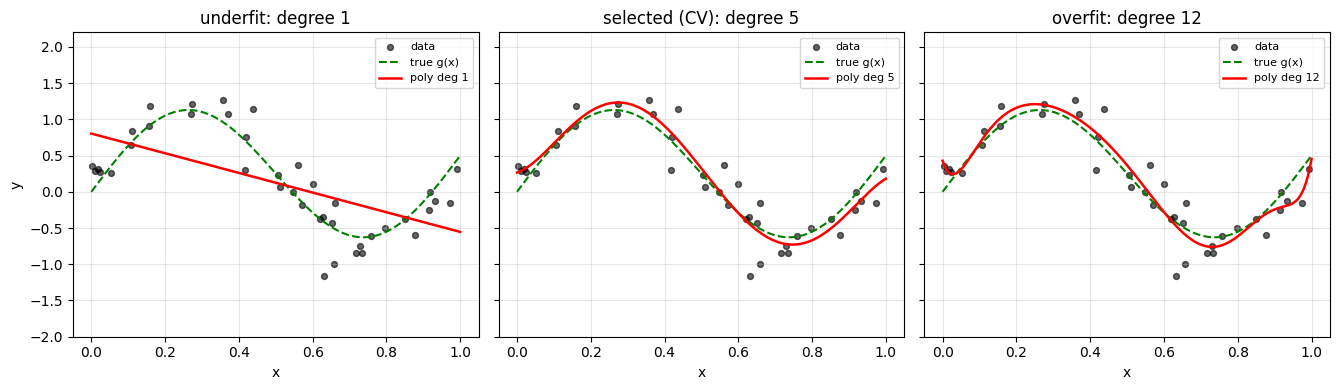

In [4]:
# --- 7) 그림 2: underfit / selected / overfit ---
xx = np.linspace(0, 1, 400)
show = [1, int(d_cv), 12]
labels = ["underfit", "selected (CV)", "overfit"]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), sharey=True)
for axk, d, lab in zip(axes, show, labels):
    yy = poly_fit_predict(x, y, xx, d)
    axk.scatter(x, y, s=18, color="black", alpha=0.6, label="data")
    axk.plot(xx, g_true(xx), "g--", lw=1.5, label="true g(x)")
    axk.plot(xx, yy, "r-", lw=1.8, label=f"poly deg {d}")
    axk.set_ylim(-2.0, 2.2)
    axk.set_title(f"{lab}: degree {d}")
    axk.set_xlabel("x"); axk.legend(fontsize=8); axk.grid(alpha=0.3)
axes[0].set_ylabel("y")
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **훈련오차는 끝없이 내려간다.** degree가 커질수록 train RMSE는 단조 감소해 잡음 수준($\sigma$) 아래로도 파고든다 — 데이터의 *잡음까지* 외운 결과이지 일반화가 좋아진 게 아니다. 훈련오차만 보고 모델을 고르면 반드시 과적합한다.
2. **CV 곡선은 U자형.** 낮은 차수는 편향(과소적합)으로, 높은 차수는 분산(과대적합)으로 검증오차가 커지고, 그 사이 **최소점**이 데이터가 지지하는 복잡도다. 최소점의 CV-RMSE는 참잡음 $\sigma$ 부근에 안착한다.
3. **BIC가 CV와 거의 일치.** 강한 벌점 $p\ln n$ 의 BIC가 CV-최소 차수와 같거나 한 단계 단순한 모델을 골라, 참함수를 몰라도 복잡도를 자동 선택할 수 있음을 보인다. AIC는 벌점이 후해 조금 더 복잡한 쪽을 허용한다.
4. **세 적합 그림**이 편향-분산을 눈으로 확인시킨다: degree 1은 곡률을 못 따라가고(편향), degree 12는 점 사이에서 요동치며(분산), 선택된 차수만 참곡선을 매끄럽게 회복한다.

> **결론**: 훈련오차는 복잡도를 *늘리라*고만 말한다 — 멈출 지점은 **CV/BIC** 가 정한다. 데이터가 스스로 고른 이 복잡도가 파이프라인의 첫 산출물이다.

**다음 문제로**: Problem 2는 여기서 **선택된 모델**을 관측구간에 적합해 *미래를* 예측하고, 잔차 부트스트랩으로 **예측구간(PI)** 을 씌워 "얼마나 믿고 외삽할 것인가"에 답한다.